## 1. Exploratory Data Analysis

In [ ]:
import pandas as pd
import os
import sys
from src.utils import show_count_plots, show_corr, show_outliers
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Current Working Directory: /content
Current Python Path:
- /content
- /env/python
- /usr/lib/python312.zip
- /usr/lib/python3.12
- /usr/lib/python3.12/lib-dynload
- 
- /usr/local/lib/python3.12/dist-packages
- /usr/lib/python3/dist-packages
- /usr/local/lib/python3.12/dist-packages/IPython/extensions
- /root/.ipython
- /content/drive/My Drive/YourProjectFolder
- /content/drive/MyDrive/Computers/My Laptop/YourProjectFolder
- /content/drive/My Drive/dvga27

Contents of /content/drive/Computers/ (top level):
ls: cannot access '/content/drive/Computers/': No such file or directory


ModuleNotFoundError: No module named 'src'

In [ ]:
raw_path = os.path.dirname(os.path.abspath('.'))

save_cls_dis = '..\plots'
save_data_corr = '..\plots'
save_data_ol = '..\plots'

dataset_path = os.path.join(raw_path,'student-lifestyle.csv')

df = pd.read_csv(dataset_path)

In [ ]:
df.head()

In [ ]:
df.tail()

In [ ]:
print(f'Dataset Shape is {df.shape}')

In [ ]:
for col in df.columns[1:]:
    print(f'{col} Describe: \n{df[col].describe()}')
    print("="*40)

In [ ]:
hour_cols = ['Sleep_Hours', 'Study_Hours', 'Social_Media_Hours']
for col in hour_cols:
    df[col] = df[col].clip(lower=0, upper=24, axis=0, inplace=True)
df['Attendance'] = df['Attendance'].clip(lower=0, upper=100, axis = 0, inplace=True)

invalid = df[df[hour_cols].sum(axis=1) > 24].index
print(f"Dropping {len(invalid)} rows out of {len(df)}")

df.drop(index=invalid, inplace=True)

In [ ]:
df.info()

In [ ]:
df.isna().sum()

In [ ]:
df.dropna(axis=0, how='any', inplace=True)

In [ ]:
df['Stress_Level'].value_counts()

In [ ]:
df['Student_Type'].value_counts()

In [ ]:
sorted(set(df['Stress_Level'].values))

In [ ]:
show_count_plots(df, 'Stress_Level', save_path=os.path.join(save_cls_dis, 'Stress Level chart.png'))

In [ ]:
show_count_plots(df, 'Student_Type', save_path=os.path.join(save_cls_dis, 'Student Type chart.png'))

In [ ]:
df_dummies = pd.get_dummies(df['Student_Type'], dtype=int)
df_dummies

In [ ]:
df.drop('Student_Type', inplace=True, axis=1)
df = pd.concat([df,df_dummies], axis=1)
df

In [ ]:
show_corr(df, save_path=os.path.join(save_data_corr, 'Full data corr.png'))

In [ ]:
show_outliers(df[df.columns[:-4]], save_path=os.path.join(save_data_ol, 'Full data outliers.png'))

## 2.Preprocessing and feature engineering

In [ ]:
import os
import sys
sys.path.append(os.path.abspath('..'))

from src.utils import show_corr,remove_outliers_iqr,show_outliers
from src.data_loader import load_data
from src.feature_extraction import build_features

import pandas as pd
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [ ]:
df = load_data(dataset_path)

In [ ]:
df

In [ ]:
df.dropna(axis=0, how='any', inplace=True)

hour_cols = ['Sleep_Hours', 'Study_Hours', 'Social_Media_Hours']
for col in hour_cols:
    df[col].clip(lower=0, upper=24, axis=0, inplace=True)
df['Attendance'] = df['Attendance'].clip(lower=0, upper=100, axis = 0, inplace=True)

invalid = df[df[hour_cols].sum(axis=1) > 24].index
print(f"Dropping {len(invalid)} rows out of {len(df)}")

df.drop(index=invalid, axis=0, inplace=True)

df = remove_outliers_iqr(df, hour_cols)

In [ ]:
df.shape

In [ ]:
df_FE = build_features(df)
df_FE.dropna(axis=0, how='any', inplace=True)

In [ ]:
df_FE.head()

In [ ]:
show_corr(df)

In [ ]:
show_corr(df_FE, save_path=os.path.join(save_data_corr, "Feature Engineer corr"), h=25, w=20)

In [ ]:
from sklearn.model_selection import train_test_split

df_FE_train, df_FE_test = train_test_split(df_FE, test_size=0.25, stratify=df_FE['Stress_Level'], random_state=42)

In [ ]:
df_FE_train.to_csv(os.path.join(raw_path,'df_FE_train.csv'), index=False)
df_FE_test.to_csv(os.path.join(raw_path,'df_FE_test.csv'), index=False)

## 3. Baseline Models

In [ ]:
from pytabkit import RealMLP_TD_Classifier
from pytabkit import TabM_D_Classifier

from sklearn.ensemble import ExtraTreesClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
import pandas as pd

import os
import sys
sys.path.append(os.path.abspath('..'))

from src.models import train_pipline
from src.utils import show_confusion_matrix

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [ ]:
raw_path = os.path.dirname(os.path.abspath('.'))
df_FE_train_path = os.path.join(raw_path, "df_FE_train.csv")
df_FE_test_path = os.path.join(raw_path, "df_FE_test.csv")

df_FE = pd.read_csv(df_FE_train_path)

df_FE.shape

In [ ]:
X = df_FE.drop(['Stress_Level'], axis=1)
y = df_FE['Stress_Level']

In [ ]:
X

In [ ]:
X.columns

In [ ]:
y

In [ ]:
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

target_names=['0','1']

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [ ]:
y_resampled.value_counts()

In [ ]:
ET_model,y_preds,y_probas = train_pipline(X_resampled,y_resampled,ExtraTreesClassifier,cv=cv)
show_confusion_matrix(y_resampled,y_preds,target_names)
print(classification_report(y_resampled,y_preds,target_names=target_names))

In [ ]:
LGBM_model,y_preds,y_probas = train_pipline(X_resampled,y_resampled,LGBMClassifier,cv=cv)
show_confusion_matrix(y_resampled,y_preds,target_names)
print(classification_report(y_resampled,y_preds,target_names=target_names))

In [ ]:
XGB_model,y_preds, y_probas = train_pipline(X_resampled,y_resampled,XGBClassifier,cv=cv)
show_confusion_matrix(y_resampled,y_preds,target_names)
print(classification_report(y_resampled,y_preds,target_names=target_names))

In [ ]:
fi = pd.DataFrame({'features': X.columns,
                   'importances': ET_model.feature_importances_})

fi.sort_values('importances',ascending=False)

In [ ]:
fi = pd.DataFrame({'features': X.columns,
                   'importances': LGBM_model.feature_importances_})

fi.sort_values('importances',ascending=False)

In [ ]:
fi = pd.DataFrame({'features': X.columns,
                   'importances': XGB_model.feature_importances_})

fi.sort_values('importances',ascending=False)

## 4. Hyperparameter Tuning

In [ ]:
import os
import sys
sys.path.append(os.path.abspath('..'))

from src.models import train_pipline,auto_tune
from src.utils import show_confusion_matrix,plot_roc_curve

from pytabkit import RealMLP_TD_Classifier
from pytabkit import TabM_D_Classifier
from sklearn.ensemble import ExtraTreesClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report

import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

c:\Users\Georgii\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
raw_path = os.path.dirname(os.path.abspath('.'))

df_FE_train_path = os.path.join(raw_path, "df_FE_train.csv")
df_FE_test_path = os.path.join(raw_path, "df_FE_test.csv")

df_FE = pd.read_csv(df_FE_train_path)
df_FE_test= pd.read_csv(df_FE_test_path)

X = df_FE.drop(['Stress_Level'], axis=1)
y = df_FE['Stress_Level']

X

,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Student_Type_college,Student_Type_school,Student_Type_working_student,...,Attendance_x_Study_Hours,Study_per_Sleep,Social_to_Study_ratio,Free_Time_to_Social_ratio,Sleep_Deficit,Low_Attendance,Low_Study,High_Social,Month_sin,Month_cos
0,5.924492,7.049828,6.452720,66.293020,9.0,6.0,9.0,1,0,0,...,467.354364,1.189946,0.915302,1.708687,1,0,0,1,-1.000000,-1.836970e-16
1,6.593804,2.036168,6.946622,90.388951,3.0,7.0,7.0,0,1,0,...,184.047113,0.308800,3.411615,2.212590,0,0,1,1,-0.500000,-8.660254e-01
2,6.324738,7.506127,3.319417,73.332499,2.0,6.0,4.0,0,0,1,...,550.443077,1.186789,0.442228,3.063530,0,0,0,0,0.866025,-5.000000e-01
3,8.690729,1.934664,2.357042,79.517807,5.0,5.0,7.0,1,0,0,...,153.840260,0.222612,1.218321,5.674318,0,0,1,0,-0.500000,-8.660254e-01
4,6.103824,2.873397,2.107474,81.292194,4.0,9.0,7.0,1,0,0,...,233.584762,0.470754,0.733443,7.128336,0,0,1,0,-0.500000,-8.660254e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13078,8.231310,6.487739,2.082401,99.389547,6.0,5.0,2.0,1,0,0,...,644.813433,0.788178,0.320975,4.456851,0,0,0,0,0.866025,5.000000e-01
13079,7.703259,2.985554,5.369218,76.201046,2.0,7.0,11.0,0,1,0,...,227.502371,0.387570,1.798399,2.479167,0,0,1,1,-0.500000,8.660254e-01
13080,6.575895,4.860778,4.204673,73.109303,2.0,6.0,5.0,0,0,1,...,355.368123,0.739181,0.865021,2.987944,0,0,0,1,0.500000,-8.660254e-01
13081,4.438425,5.911327,2.302156,95.262969,5.0,7.0,4.0,1,0,0,...,563.130527,1.331852,0.389448,5.929332,1,0,0,0,0.866025,-5.000000e-01


In [ ]:
y

0        1
1        0
2        0
3        0
4        0
        ..
13078    0
13079    0
13080    1
13081    0
13082    1
Name: Stress_Level, Length: 13083, dtype: int64

In [ ]:
target_names = ['0', '1']

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [ ]:
y_resampled

0        1
1        0
2        0
3        0
4        0
        ..
18401    1
18402    1
18403    1
18404    1
18405    1
Name: Stress_Level, Length: 18406, dtype: int64

In [ ]:
y_resampled.value_counts()

Stress_Level
1    9203
0    9203
Name: count, dtype: int64

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
LGBM_params = {
    "n_estimators":("int", 800,2000),
    "max_depth": ("int", 5,9),
    "learning_rate": ("float", 0.02, 0.15,True),
    "subsample": ("float", 0.7, 1.0, False),
    "colsample_bytree":("float", 0.6, 1.0, False),
    "num_leaves": ("int", 50, 200),
    "min_child_samples": ("int", 10, 50),
    "reg_alpha": ("float", 1e-4, 1.0, True),
    "reg_lambda": ("float", 1e-4, 1.0, True),
    'verbose':-1,
}

XGB_params = {
    "n_estimators": ("int",800,2000),
    "max_depth": ("int", 4,8),
    "learning_rate": ("float", 0.02,0.15,True),
    "subsample": ("float", 0.7, 1.0, False),
    "colsample_bytree": ("float", 0.6, 1.0, False),
    "min_child_weight": ("int", 1, 10),
    "reg_alpha": ("float", 1e-4, 1.0, True),
    "reg_lambda":("float", 1e-4, 1.0, True),
    "gamma":  ("float", 0, 0.5, False),
    'verbosity':0,
}

In [ ]:
# LGBM_study = auto_tune(X_resampled, y_resampled, model_class=LGBMClassifier, tuning_params=LGBM_params, cv=cv, n_trials=30)
# print(LGBM_study.best_params)
# print(LGBM_study.best_value)

In [ ]:
# XGB_study = auto_tune(X_resampled,y_resampled,XGBClassifier,XGB_params,cv=cv,n_trials=15)
# print(XGB_study.best_params)
# print(XGB_study.best_value)

In [ ]:
LGBM_BEST_PARAMS = {'n_estimators': 1036,
                    'max_depth': 7,
                    'learning_rate': 0.020935396373398023,
                    'subsample': 0.992166101648227,
                    'colsample_bytree': 0.7494380846087404,
                    'num_leaves': 67,
                    'min_child_samples': 45,
                    'reg_alpha': 0.0006650797129419691,
                    'reg_lambda': 0.20479605091612718}

XGB_BEST_PARAMS = {'n_estimators': 1007,
                   'max_depth': 7,
                   'learning_rate': 0.020066611690613374,
                   'subsample': 0.7013046414240078,
                   'colsample_bytree': 0.7447371598997203,
                   'min_child_weight': 9,
                   'reg_alpha': 0.0015993208674721017,
                   'reg_lambda': 0.0060640794884617094,
                   'gamma': 0.09967898557240965}

Cross Validating with RealMLP_TD_Classifier Model Now...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer.fit` stopped: `max_epochs=256` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
GPU available: False, used: False
TP

Fold 1: 0.86801


`Trainer.fit` stopped: `max_epochs=256` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Fold 2: 0.85955


...

Fold 3: 0.85765


`Trainer.fit` stopped: `max_epochs=256` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Fold 4: 0.86416


`Trainer.fit` stopped: `max_epochs=256` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Fold 5: 0.86036
Mean CV Accuracy: 0.86195



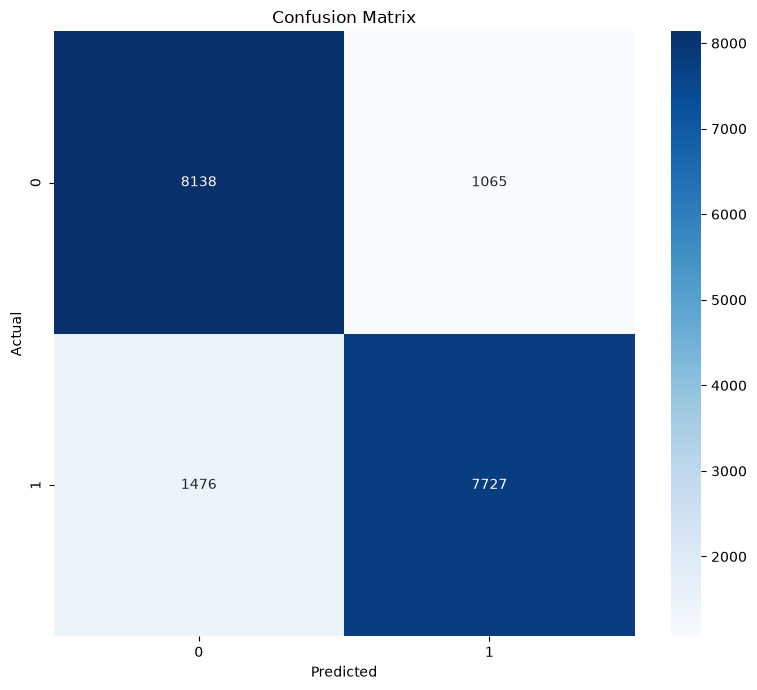

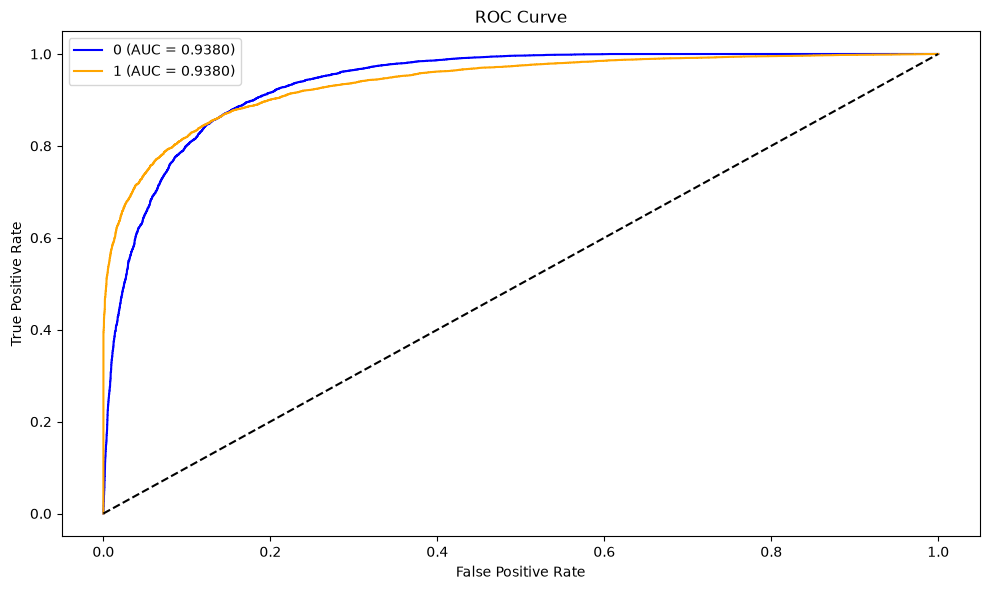

              precision    recall  f1-score   support

           0       0.85      0.88      0.86      9203
           1       0.88      0.84      0.86      9203

    accuracy                           0.86     18406
   macro avg       0.86      0.86      0.86     18406
weighted avg       0.86      0.86      0.86     18406



In [ ]:
RMLP_model, RLMP_y_preds, RLMP_y_probas = train_pipline(X_resampled, y_resampled, RealMLP_TD_Classifier, cv=cv)
show_confusion_matrix(y_resampled, RLMP_y_preds, target_names)
plot_roc_curve(y_resampled, RLMP_y_probas, target_names)
print(classification_report(y_resampled, RLMP_y_preds, target_names=target_names))

Cross Validating with TabM_D_Classifier Model Now...
Fold 1: 0.86801
Fold 2: 0.86635
Fold 3: 0.86037
Fold 4: 0.86661
Fold 5: 0.85819
Mean CV Accuracy: 0.86390



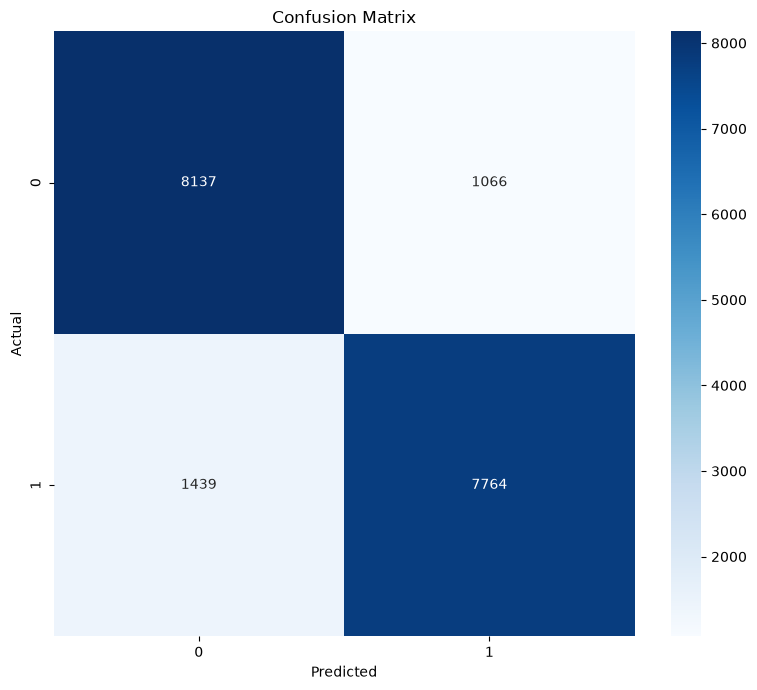

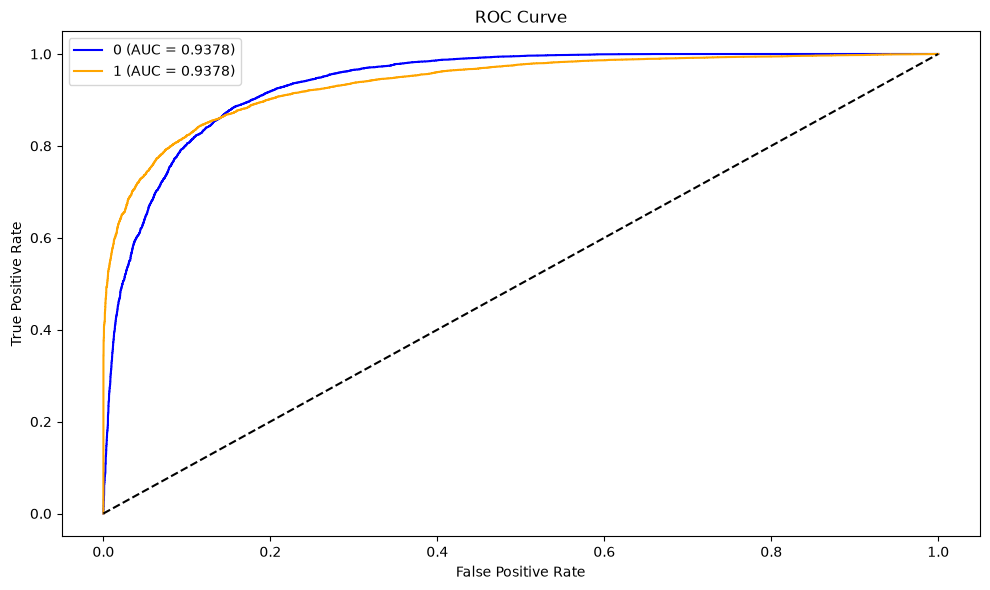

              precision    recall  f1-score   support

           0       0.85      0.88      0.87      9203
           1       0.88      0.84      0.86      9203

    accuracy                           0.86     18406
   macro avg       0.86      0.86      0.86     18406
weighted avg       0.86      0.86      0.86     18406



In [ ]:
TM_model , TM_y_preds, TM_y_probas= train_pipline(X_resampled,y_resampled,TabM_D_Classifier,cv=cv)
show_confusion_matrix(y_resampled,TM_y_preds,target_names)
plot_roc_curve(y_resampled,TM_y_probas,target_names)
print(classification_report(y_resampled,TM_y_preds,target_names=target_names))

Cross Validating with ExtraTreesClassifier Model Now...
Fold 1: 0.87968
Fold 2: 0.87096
Fold 3: 0.86688
Fold 4: 0.87205
Fold 5: 0.86363
Mean CV Accuracy: 0.87064



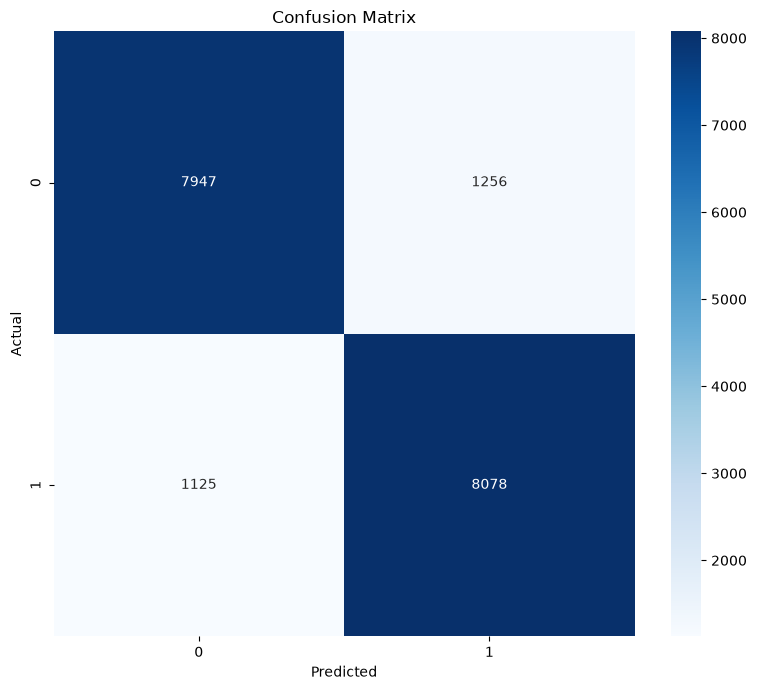

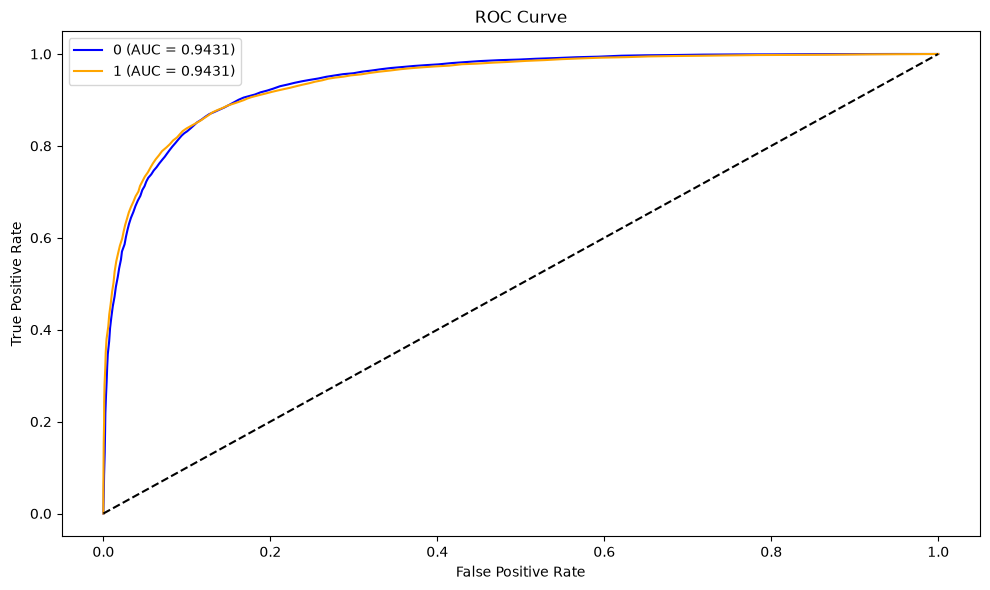

              precision    recall  f1-score   support

           0       0.88      0.86      0.87      9203
           1       0.87      0.88      0.87      9203

    accuracy                           0.87     18406
   macro avg       0.87      0.87      0.87     18406
weighted avg       0.87      0.87      0.87     18406



In [ ]:
ETC_model , ETC_y_preds, ETC_y_probas= train_pipline(X_resampled,y_resampled,ExtraTreesClassifier,cv=cv)
show_confusion_matrix(y_resampled,ETC_y_preds,target_names)
plot_roc_curve(y_resampled, ETC_y_probas, target_names)
print(classification_report(y_resampled,ETC_y_preds,target_names=target_names))

Cross Validating with LGBMClassifier Model Now...
[LightGBM] [Info] Number of positive: 7362, number of negative: 7362
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000405 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4349
[LightGBM] [Info] Number of data points in the train set: 14724, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

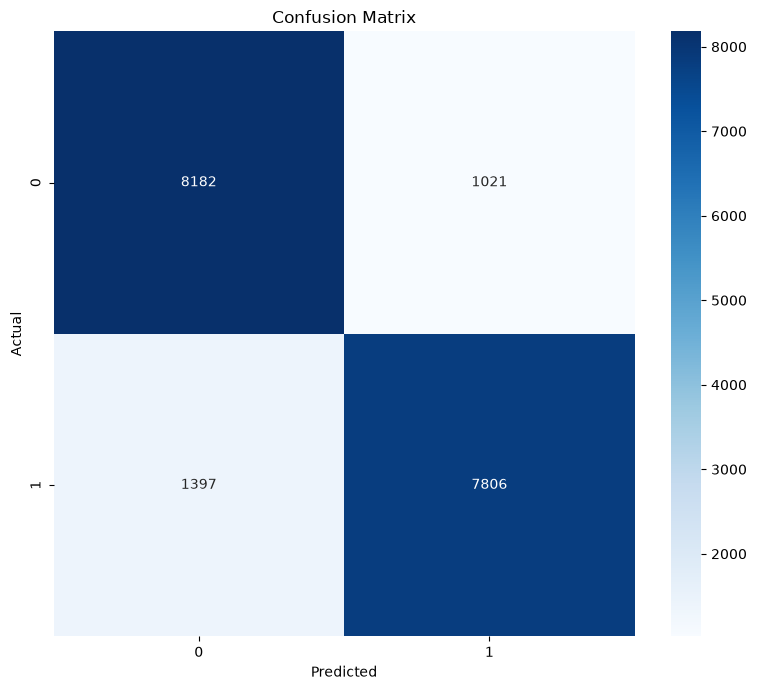

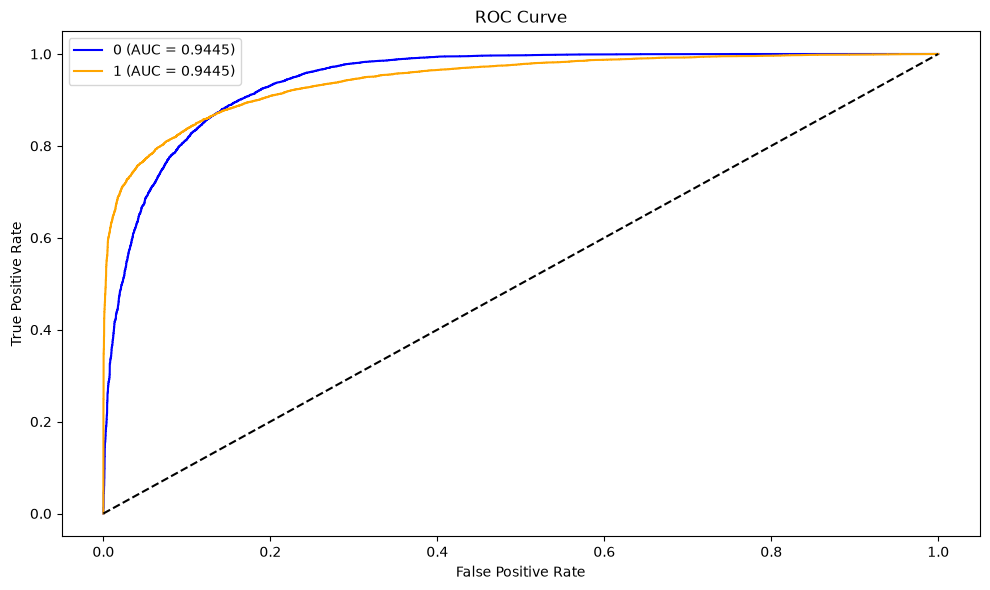

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      9203
           1       0.88      0.85      0.87      9203

    accuracy                           0.87     18406
   macro avg       0.87      0.87      0.87     18406
weighted avg       0.87      0.87      0.87     18406



In [ ]:
LGBM_model , LGBM_y_preds, LGBM_y_probas= train_pipline(X_resampled,y_resampled,LGBMClassifier,LGBM_BEST_PARAMS,cv)
show_confusion_matrix(y_resampled,LGBM_y_preds,target_names)
plot_roc_curve(y_resampled,LGBM_y_probas,target_names)
print(classification_report(y_resampled,LGBM_y_preds,target_names=target_names))

Cross Validating with XGBClassifier Model Now...
Fold 1: 0.87072
Fold 2: 0.86961
Fold 3: 0.86634
Fold 4: 0.87095
Fold 5: 0.86552
Mean CV Accuracy: 0.86863



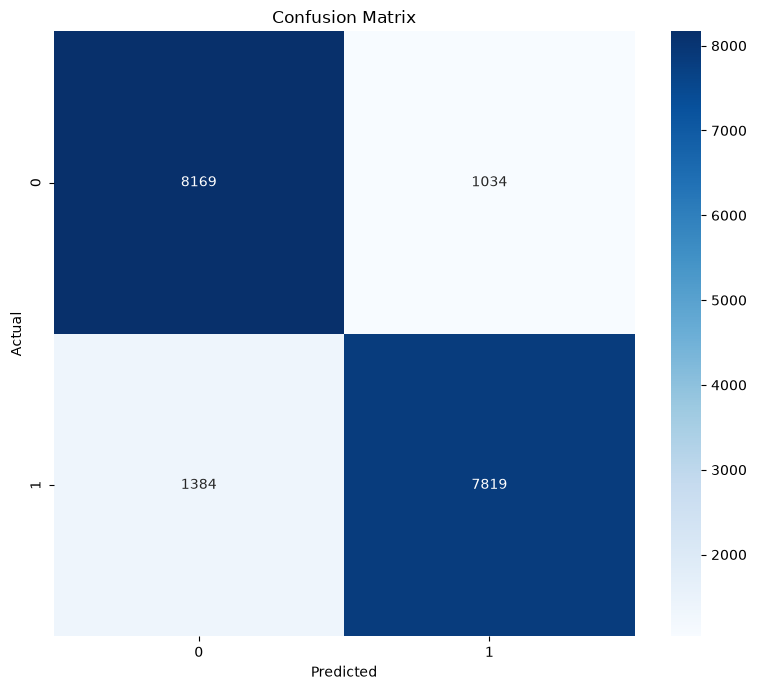

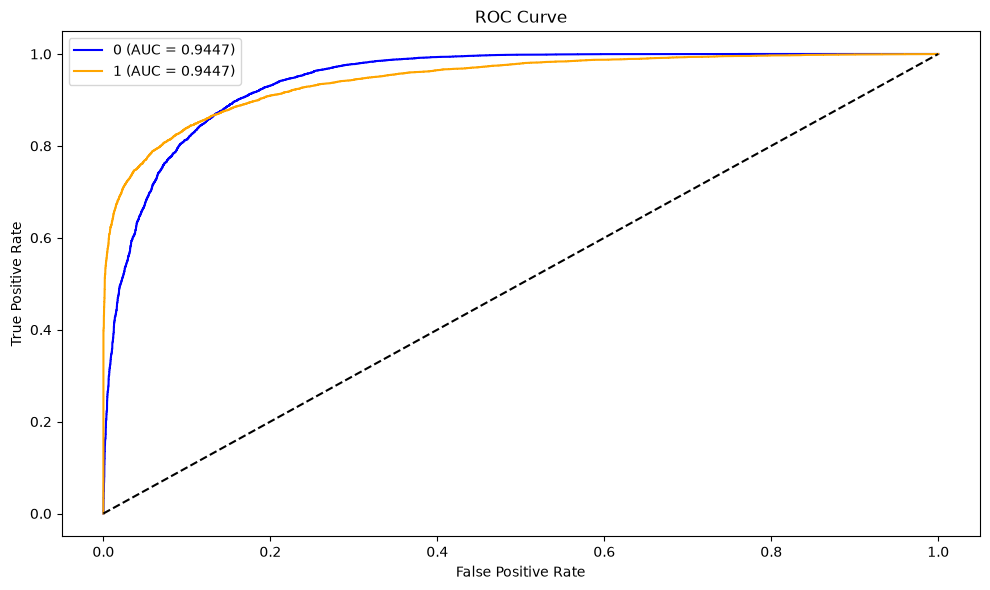

              precision    recall  f1-score   support

           0       0.86      0.89      0.87      9203
           1       0.88      0.85      0.87      9203

    accuracy                           0.87     18406
   macro avg       0.87      0.87      0.87     18406
weighted avg       0.87      0.87      0.87     18406



In [ ]:
XGB_model , XGB_y_preds, XGB_y_probas= train_pipline(X_resampled,y_resampled,XGBClassifier,XGB_BEST_PARAMS,cv)
show_confusion_matrix(y_resampled,XGB_y_preds,target_names)
plot_roc_curve(y_resampled,XGB_y_probas,target_names)
print(classification_report(y_resampled,XGB_y_preds,target_names=target_names))

In [ ]:
save_probas = '..\probas'
if not os.path.exists(save_probas):
    os.mkdir(save_probas)

np.save(os.path.join(save_probas, 'oof_RMLP_y_probas.npy'), RLMP_y_probas)
np.save(os.path.join(save_probas, 'oof_TM_y_probas.npy'), TM_y_probas)
np.save(os.path.join(save_probas, 'oof_ETC_y_probas.npy'), ETC_y_probas)
np.save(os.path.join(save_probas, 'oof_LGBM_y_probas.npy'), LGBM_y_probas)
np.save(os.path.join(save_probas, 'oof_XGB_y_probas.npy'), XGB_y_probas)

In [ ]:
cols_order = X_resampled.columns.tolist()

In [ ]:
RMLP_test_probas = train_pipline(X_resampled, y_resampled, RealMLP_TD_Classifier, X_test=df_FE_test[cols_order])
np.save(os.path.join(save_probas, 'RMLP_test_probas.npy'), RMLP_test_probas)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer.fit` stopped: `max_epochs=256` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [ ]:
TM_test_probas = train_pipline(X_resampled, y_resampled, TabM_D_Classifier, X_test=df_FE_test[cols_order])
np.save(os.path.join(save_probas, 'TM_test_probas.npy'), TM_test_probas)

In [ ]:
ETC_test_probas = train_pipline(X_resampled,y_resampled,ExtraTreesClassifier,X_test=df_FE_test[cols_order])
np.save(os.path.join(save_probas, 'ETC_test_probas.npy'), ETC_test_probas)

In [ ]:
LGBM_test_probas = train_pipline(X_resampled,y_resampled,LGBMClassifier,LGBM_BEST_PARAMS,X_test=df_FE_test[cols_order])
np.save(os.path.join(save_probas, 'LGBM_test_probas.npy'), LGBM_test_probas)

[LightGBM] [Info] Number of positive: 9203, number of negative: 9203
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000712 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4349
[LightGBM] [Info] Number of data points in the train set: 18406, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

In [ ]:
XGB_test_probas = train_pipline(X_resampled,y_resampled,XGBClassifier,XGB_BEST_PARAMS,X_test=df_FE_test[cols_order])
np.save(os.path.join(save_probas, 'XGB_test_probas.npy'), XGB_test_probas)